<a href="https://colab.research.google.com/github/encen-ya/PCVK_Genap2026/blob/main/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Citra Asli dan Masking Buatan:


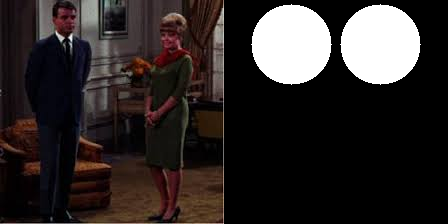


2. Hasil Operasi Logika:
NOT


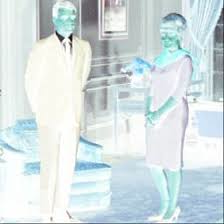

OR


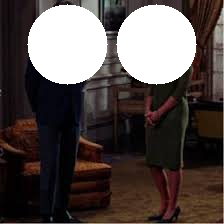

AND


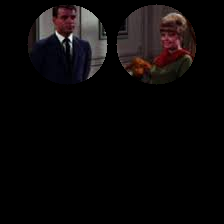

NAND


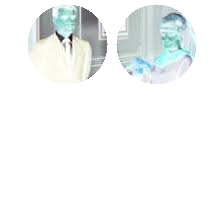

XOR


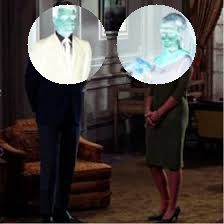

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# MASUKKAN LINK GAMBAR ASLI DI SINI
link_gambar = '/content/drive/MyDrive/KULIAH/PCVK/Images/couple.jpg'
original = cv.imread(link_gambar)

# 1. MEMBUAT MASKING SENDIRI (Latar hitam)
mask = np.zeros(original.shape, dtype=np.uint8)

# 2. MENGGAMBAR LINGKARAN PUTIH PADA MASK
# cv.circle(image, center_coordinate, radius, color, thickness)
# Koordinat (x, y) di bawah ini adalah perkiraan, silakan ubah angkanya
# agar pas berada di wajah pria dan wanita pada gambar couple.tiff
tinggi, lebar, _ = original.shape
cv.circle(mask, (int(lebar*0.3), int(tinggi*0.2)), 40, (255, 255, 255), -1) # Wajah kiri
cv.circle(mask, (int(lebar*0.7), int(tinggi*0.2)), 40, (255, 255, 255), -1) # Wajah kanan

# --- OPERASI LOGIKA SESUAI TABEL TUGAS 9 ---

# 1. NOT (Komplemen) - Membalikkan warna citra asli (tidak butuh mask)
img_not = cv.bitwise_not(original)

# 2. OR (Atau) - Menggabungkan citra asli dengan mask putih
img_or = cv.bitwise_or(original, mask)

# 3. AND (Dan) - Mengambil bagian citra asli HANYA pada area putih mask
img_and = cv.bitwise_and(original, mask)

# 4. NAND (Not And) - Kebalikan dari hasil AND
img_nand = cv.bitwise_not(img_and)

# 5. XOR (Exclusive Or)
img_xor = cv.bitwise_xor(original, mask)

# Menampilkan semua hasil untuk dianalisa
print("1. Citra Asli dan Masking Buatan:")
cv2_imshow(cv.hconcat((original, mask)))

print("\n2. Hasil Operasi Logika:")
print("NOT")
cv2_imshow(img_not)
print("OR")
cv2_imshow(img_or)
print("AND")
cv2_imshow(img_and)
print("NAND")
cv2_imshow(img_nand)
print("XOR")
cv2_imshow(img_xor)

Jumlah Citra di Average: 100
Nilai PSNR: 32.47 dB


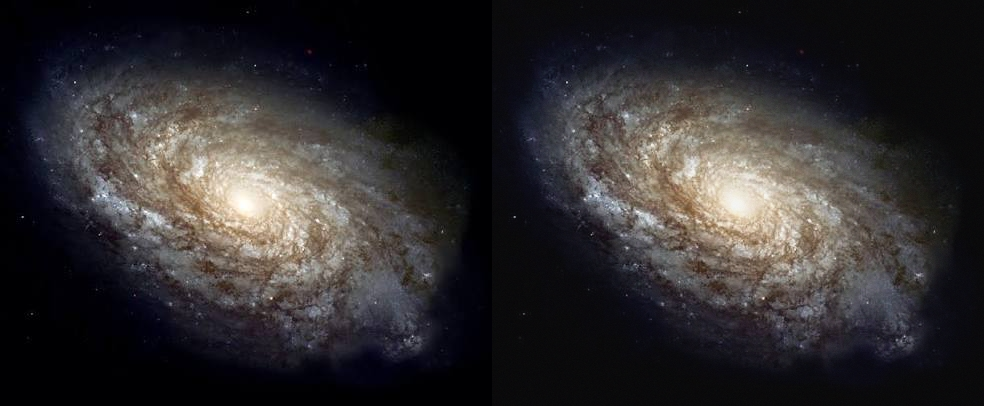

In [24]:
import glob
import math

def calculate_psnr(img1, img2):
    # Rumus PSNR
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * math.log10(max_pixel / math.sqrt(mse))
    return psnr

link_folder_noises = '/content/drive/MyDrive/KULIAH/PCVK/Images/noises/*.jpg'
link_asli = '/content/drive/MyDrive/KULIAH/PCVK/Images/galaxy.jpg'

citra_asli = cv.imread(link_asli)

jumlah_average = 100
cv_img = []

for img in glob.glob(link_folder_noises)[:jumlah_average]:
    n = cv.imread(img)
    cv_img.append(n)

average_image_float = np.zeros(citra_asli.shape, dtype=float)

for img in cv_img:
    average_image_float = average_image_float + img

average_image_float = average_image_float / jumlah_average

average_image = average_image_float.astype(np.uint8)

nilai_psnr = calculate_psnr(citra_asli, average_image)
print(f"Jumlah Citra di Average: {jumlah_average}")
print(f"Nilai PSNR: {nilai_psnr:.2f} dB")

cv2_imshow(cv.hconcat((citra_asli, average_image)))

In [17]:
import cv2 as cv
import numpy as np
import os

link_asli = '/content/drive/MyDrive/KULIAH/PCVK/Images/galaxy.jpg'
folder_tujuan = '/content/drive/MyDrive/KULIAH/PCVK/Images/noises/'


# Baca gambar asli
citra_asli = cv.imread(link_asli)

print("Mulai membuat 100 gambar dengan Gaussian Noise...")

for i in range(1, 101):

    gaussian_noise = np.random.normal(0, 25, citra_asli.shape).astype(np.float32)


    citra_bernoise = citra_asli.astype(np.float32) + gaussian_noise

    citra_bernoise = np.clip(citra_bernoise, 0, 255).astype(np.uint8)

    # 3. Simpan hasil citra ke folder tujuan
    nama_file = f"noise_{i:03d}.jpg"
    cv.imwrite(os.path.join(folder_tujuan, nama_file), citra_bernoise)

print(f"Selesai! 100 gambar telah tersimpan di {folder_tujuan}")

Mulai membuat 100 gambar dengan Gaussian Noise...
Selesai! 100 gambar telah tersimpan di /content/drive/MyDrive/KULIAH/PCVK/Images/noises/


Masukkan bit depth tujuan (1-8): 3
Bit depth awal : 8 bit
Bit depth tujuan : 3 bit
Jumlah level : 8


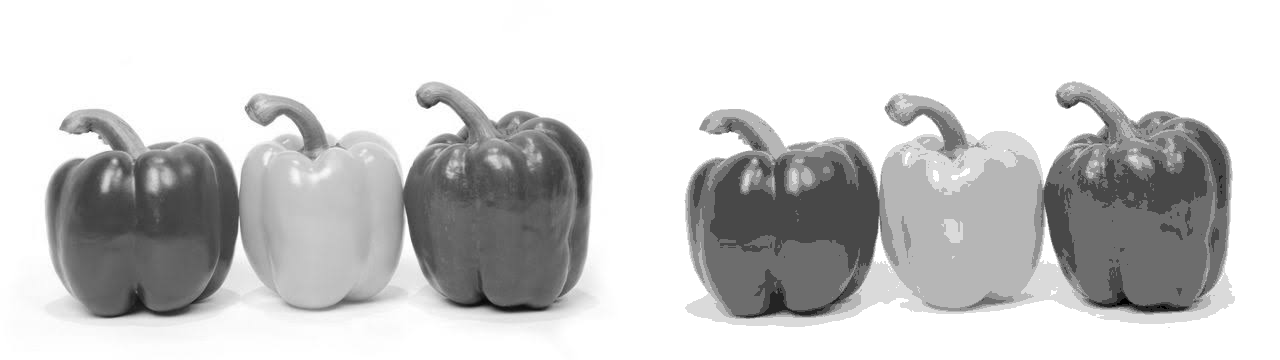

In [5]:
try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))
except ValueError:
    print('Error, not a number')

# Menghitung level
level = 255.0 / (pow(2, bit_depth) - 1)

link_gambar = '/content/drive/MyDrive/KULIAH/PCVK/Images/paprika.jpg'
original = cv.imread(link_gambar, cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        C = original[y,x]
        # Operasi depth
        hasil = round((C / level)) * level
        depth_image[y,x] = np.clip(hasil, 0, 255)

final_frame = cv.hconcat((original, depth_image))
print(f'Bit depth awal : 8 bit')
print(f'Bit depth tujuan : {bit_depth} bit')
print(f'Jumlah level : {pow(2, bit_depth)}')
cv2_imshow(final_frame)

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 0.5


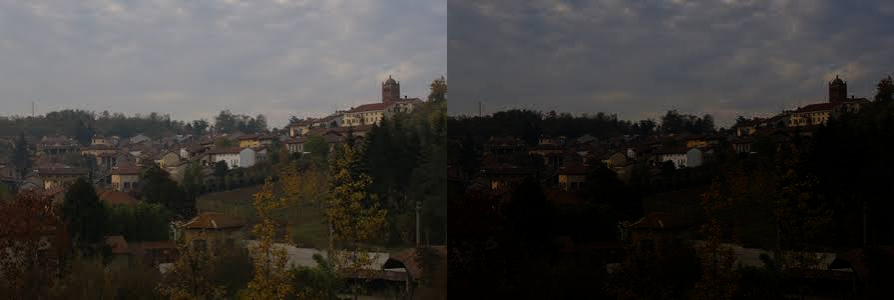

In [4]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')

link_gambar = '/content/drive/MyDrive/KULIAH/PCVK/Images/houses.jpg'
original = cv.imread(link_gambar)
gamma_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            I = original[y,x,c]
            # Rumus gamma correction (pangkat inverse dari nilai input gamma)
            hasil = 255 * ( (I / 255.0) ** (1.0 / gamma) )
            gamma_image[y,x,c] = np.clip(hasil, 0, 255)

final_frame = cv.hconcat((original, gamma_image))
cv2_imshow(final_frame)

 Mempertahankan warna tertentu (Merah) dan mengubah sisanya menjadi grayscale 
--------------------------------------------------------------------


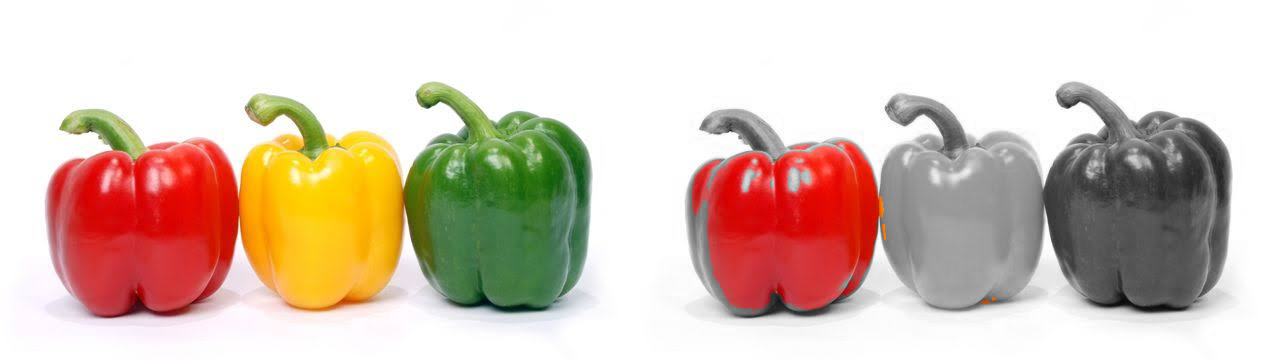

In [ ]:
print(' Mempertahankan warna tertentu (Merah) dan mengubah sisanya menjadi grayscale ')
print('--------------------------------------------------------------------')

link_gambar = '/content/drive/MyDrive/KULIAH/PCVK/Images/paprika.jpg'
original = cv.imread(link_gambar)
color_kept_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        B = int(original[y,x,0])
        G = int(original[y,x,1])
        R = int(original[y,x,2])


        if R > 150 and (R - G) > 115 and (R - B) > 115:
            color_kept_image[y,x] = [B, G, R]
        else:
            # Ubah menjadi grayscale (metode averaging)
            gray = (R + G + B) // 3
            color_kept_image[y,x] = [gray, gray, gray]

final_frame = cv.hconcat((original, color_kept_image))
cv2_imshow(final_frame)

Averaging:


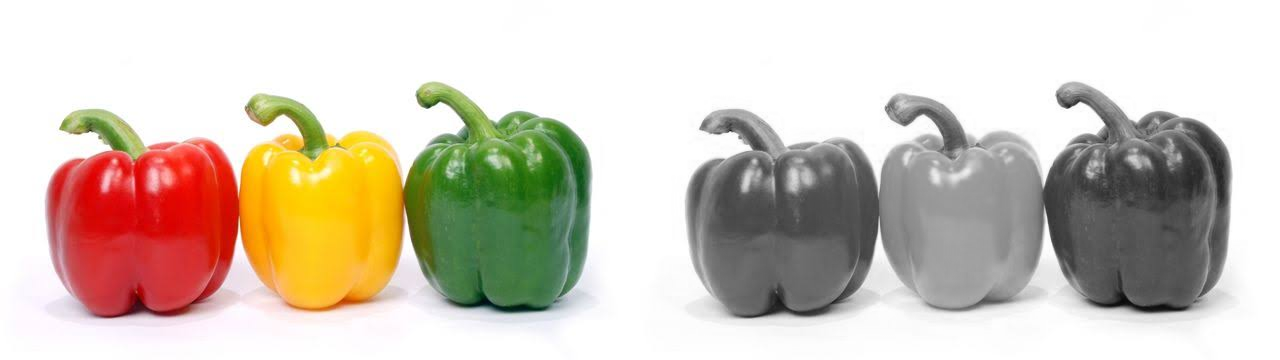

Lightness:


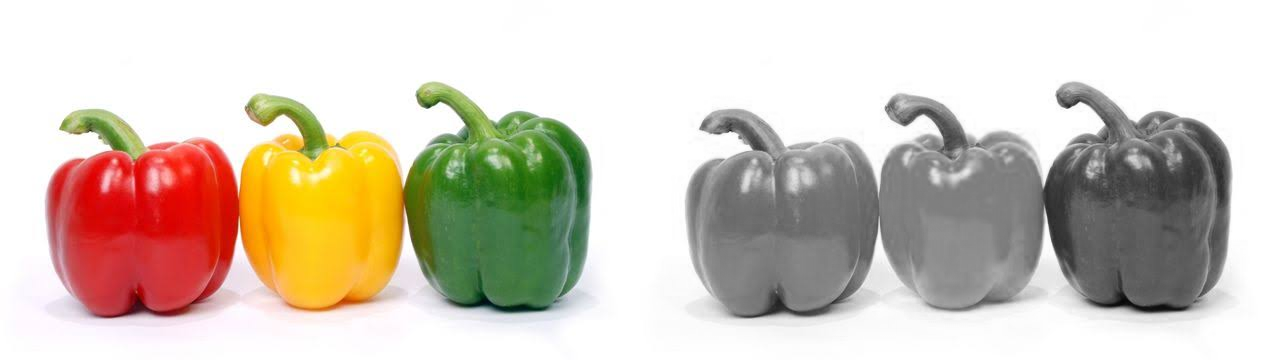

Luminance:


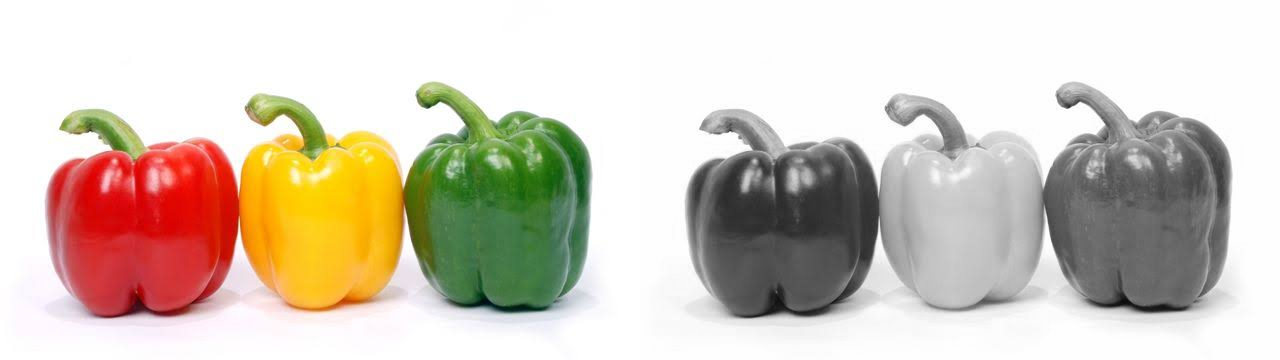

In [ ]:

link_gambar = '/content/drive/MyDrive/KULIAH/PCVK/Images/paprika.jpg'
original = cv.imread(link_gambar)

img_avg = np.zeros(original.shape, original.dtype)
img_lightness = np.zeros(original.shape, original.dtype)
img_luminance = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        B = int(original[y,x,0])
        G = int(original[y,x,1])
        R = int(original[y,x,2])

        # Averaging = (R+G+B)/3
        avg = (R + G + B) // 3
        img_avg[y,x] = (avg, avg, avg)

        # Lightness = (max(R,G,B) + min(R,G,B)) / 2
        light = (max(R,G,B) + min(R,G,B)) // 2
        img_lightness[y,x] = (light, light, light)

        # Luminance = 0.21R + 0.72G + 0.07B
        lumi = int((0.21 * R) + (0.72 * G) + (0.07 * B))
        img_luminance[y,x] = (lumi, lumi, lumi)

print("Averaging:")
cv2_imshow(cv.hconcat((original, img_avg)))
print("Lightness:")
cv2_imshow(cv.hconcat((original, img_lightness)))
print("Luminance:")
cv2_imshow(cv.hconcat((original, img_luminance)))

 Mengubah kontras dan tingkat kecerahan citra 
----------------------------------
Masukkan tingkat kecerahan: 10
Masukkan kontras: 1.5


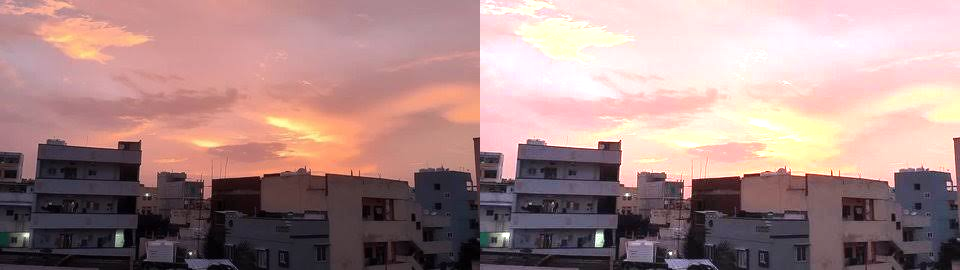

In [ ]:
print(' Mengubah kontras dan tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan tingkat kecerahan: '))
    kontras = float(input('Masukkan kontras: '))
except ValueError:
    print('Error, not a number')

link_gambar = '/content/drive/MyDrive/KULIAH/PCVK/Images/sky.jpg'
original = cv.imread(link_gambar)
contrast_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            hasil = (kontras * original[y,x,c]) + brightness
            contrast_image[y,x,c] = np.clip(hasil, 0, 255)

final_frame = cv.hconcat((original, contrast_image))
cv2_imshow(final_frame)

 Mengubah citra menjadi inverse 
----------------------------------


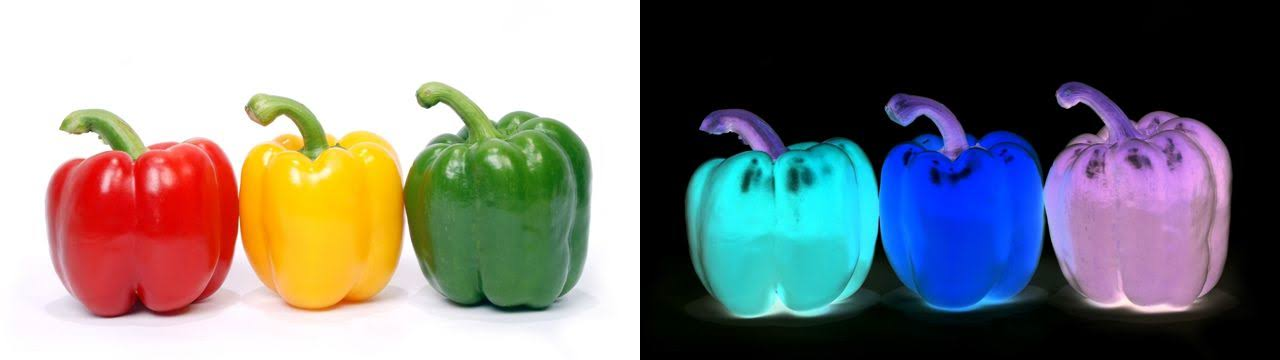

In [ ]:
print(' Mengubah citra menjadi inverse ')
print('----------------------------------')

link_gambar = '/content/drive/MyDrive/KULIAH/PCVK/Images/paprika.jpg'
original = cv.imread(link_gambar)
inverse_image = np.zeros(original.shape, original.dtype)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):

            inverse_image[y,x,c] = 255 - original[y,x,c]

final_frame = cv.hconcat((original, inverse_image))
cv2_imshow(final_frame)

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 30


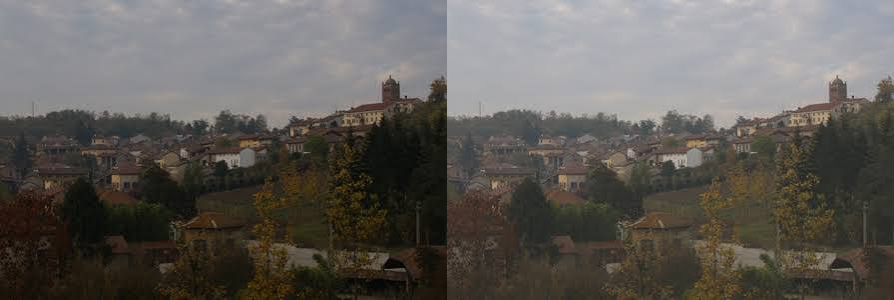

In [ ]:
print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
    brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
    print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/KULIAH/PCVK/Images/houses.jpg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

In [3]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import drive
import glob

# Mount Google Drive
drive.mount('/content/drive')

def load_img(path):
    return cv.imread(path)

Mounted at /content/drive
